# Basics of ML

**Q: Perform Regression and Decision Tree**

In [1]:
import sys

sys.path.append('..')  # allows Python to look one directory up (the repo root)
from constants import RANDOM_SEED
from utils import set_seed

set_seed()

import pandas as pd
import numpy as np

df1 = pd.read_csv('D:/CitrusBits/pythonic-rebirth/datasets/car_prices_dataset_train.csv')
df2 = pd.read_csv('D:/CitrusBits/pythonic-rebirth/datasets/car_prices_dataset_test.csv')

In [2]:
df1.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [3]:
df2.head()

,ID,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags,Price
0,44020629,-,VOLKSWAGEN,Golf,2012,Hatchback,No,Diesel,2.0 Turbo,0 km,4,Manual,Front,02-Mar,Left wheel,Grey,10,NaN
1,45784798,-,HYUNDAI,Sonata,2012,Sedan,Yes,Petrol,2.4,26000 km,4,Tiptronic,Front,04-May,Left wheel,Grey,10,NaN
2,45800257,-,NISSAN,Tiida,2005,Sedan,No,Petrol,1.5,168000 km,4,Automatic,Front,04-May,Right-hand drive,Sky blue,8,NaN
3,45797981,975,VOLVO,XC90,2012,Jeep,Yes,Petrol,3.2,143000 km,6,Automatic,4x4,04-May,Left wheel,Blue,12,NaN
4,45814303,-,OPEL,Astra,1993,Hatchback,No,Petrol,1.6,200000 km,4,Manual,Front,04-May,Left wheel,Black,0,NaN


In [4]:
df1.shape

(19237, 18)

In [5]:
# df2.shape
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [6]:
# preprocessing

# dropping ID as it is not useful for model training
if 'ID' in df1.columns:
    df1 = df1.drop('ID', axis=1)
if 'ID' in df2.columns:
    df2 = df2.drop('ID', axis=1)

# making changes in levy
for df in [df1, df2]:
    if not pd.api.types.is_numeric_dtype(df['Levy']):
        df['Levy'] = df['Levy'].replace('-', np.nan)
        df['Levy'] = pd.to_numeric(df['Levy'])

print("Levy missing %:", df1['Levy'].isnull().mean() * 100)
print(df1['Levy'].dtype)



Levy missing %: 30.24899932421895
float64


In [7]:
# fixing engine volume column now, making a separate bool or flag for turbo

for df in [df1, df2]:
    if not pd.api.types.is_numeric_dtype(df['Engine volume']):
        df['is_turbo'] = df['Engine volume'].str.contains('Turbo').astype(int)
        df['Engine volume'] = df['Engine volume'].str.replace(' Turbo', '', regex=False).astype(float)

print(df1['Engine volume'].dtype)  # should now show float64
print(df1[['Engine volume', 'is_turbo']].head())

float64
   Engine volume  is_turbo
0            3.5         0
1            3.0         0
2            1.3         0
3            2.5         0
4            1.3         0


In [8]:
if df['Engine volume'].dtype == 'object':
    df1[['Engine volume', 'is_turbo']].head(50)  # checking

In [9]:
# removing the km from milage
for df in [df1, df2]:
    df['Mileage'] = df['Mileage'].str.replace(' km', '', regex=False).astype(int)

In [10]:
print(df1['Mileage'].head())
# print(df1['Mileage'].describe())


0    186005
1    192000
2    200000
3    168966
4     91901
Name: Mileage, dtype: int64


In [11]:
# fixing the door map

door_map = {'02-Mar': 2, '04-May': 4, '>5': 5}

for df in [df1, df2]:
    df['Doors'] = df['Doors'].map(door_map)

In [12]:
print(df1['Doors'].value_counts())

Doors
4    18332
2      777
5      128
Name: count, dtype: int64


This is where the actual "capping" happens. Let's break down .where() since it's the less familiar method here:
**.where(condition, other)** works like this: "keep the original value where the condition is True; otherwise, replace it with other.

In [13]:
# handling the column model
top_models = df1['Model'].value_counts().nlargest(30).index

df1['Model'] = df1['Model'].where(df1['Model'].isin(top_models), 'Other')
df2['Model'] = df2['Model'].where(df2['Model'].isin(top_models), 'Other')

In [14]:
print(df1['Model'].value_counts())

Model
Other         8485
Prius         1083
Sonata        1079
Camry          938
Elantra        922
E 350          542
Santa FE       533
FIT            446
H1             437
Tucson         429
X5             353
Aqua           331
Cruze          302
Fusion         301
Optima         233
GX 460         224
Transit        217
Highlander     216
ML 350         202
Jetta          201
Actyon         188
Civic          187
REXTON         175
RX 450         173
RAV 4          167
Astra          150
Escape         149
GX 470         147
Volt           144
Juke           143
Captiva        140
Name: count, dtype: int64


In [15]:
top_models = df1['Model'].value_counts().nlargest(30).index
print(top_models)

Index(['Other', 'Prius', 'Sonata', 'Camry', 'Elantra', 'E 350', 'Santa FE',
       'FIT', 'H1', 'Tucson', 'X5', 'Aqua', 'Cruze', 'Fusion', 'Optima',
       'GX 460', 'Transit', 'Highlander', 'ML 350', 'Jetta', 'Actyon', 'Civic',
       'REXTON', 'RX 450', 'RAV 4', 'Astra', 'Escape', 'GX 470', 'Volt',
       'Juke'],
      dtype='str', name='Model')


In [16]:
print(df1.dtypes)
print()
print("Remaining nulls:\n", df1.isnull().sum()[df1.isnull().sum() > 0])

Price                 int64
Levy                float64
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume       float64
Mileage               int64
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                 int64
Wheel                   str
Color                   str
Airbags               int64
is_turbo              int64
dtype: object

Remaining nulls:
 Levy    5819
dtype: int64


In [17]:
levy_median = df1['Levy'].median()
print("Levy median:", levy_median)

df1['Levy_was_missing'] = df1['Levy'].isnull().astype(int)
df2['Levy_was_missing'] = df2['Levy'].isnull().astype(int)

# THEN fill
df1['Levy'] = df1['Levy'].fillna(levy_median)
df2['Levy'] = df2['Levy'].fillna(levy_median)

Levy median: 781.0


Why log transform instead of just deleting all the remaining high-priced rows?
The $872k/$627k/$308k cars are probably real, deleting them would mean throwing away legitimate data just because it's inconvenient. A log transform instead compresses the scale (turns "26,307,500 vs 5,331" type gaps into much smaller, more manageable differences) without discarding any real information. This is the standard technique for right-skewed monetary data, and you'll likely see this pattern again in Data Mining or any dataset involving prices, income, or similar values.

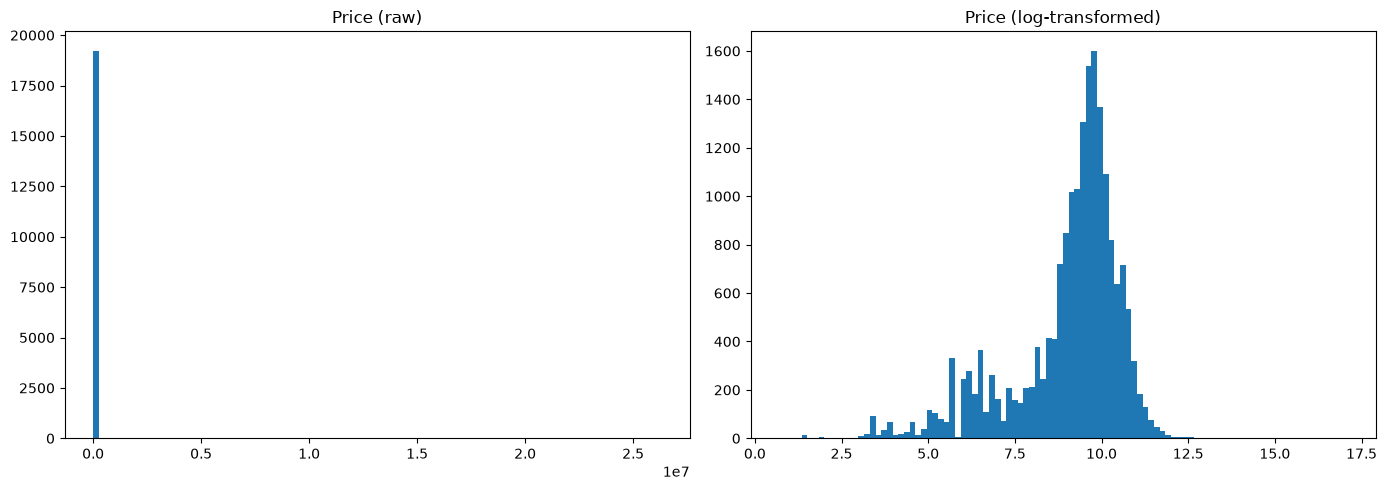

In [19]:
import matplotlib.pyplot as plt

# log transformation
df1['Price_log'] = np.log1p(df1['Price'])  # log1p = log(1 + x), handles the transform safely

X = df1.drop(['Price', 'Price_log'], axis=1)
y = df1['Price_log']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df1['Price'], bins=100)
axes[0].set_title("Price (raw)")

axes[1].hist(df1['Price_log'], bins=100)
axes[1].set_title("Price (log-transformed)")
plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.125, random_state=42)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (13465, 18) Val: (1924, 18) Test: (3848, 18)


In [21]:
print(X_train.dtypes)

Levy                float64
Manufacturer            str
Model                   str
Prod. year            int64
Category                str
Leather interior        str
Fuel type               str
Engine volume       float64
Mileage               int64
Cylinders           float64
Gear box type           str
Drive wheels            str
Doors                 int64
Wheel                   str
Color                   str
Airbags               int64
is_turbo              int64
Levy_was_missing      int64
dtype: object


In [22]:
 # LabelEncoder for the 2 binary columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for df in [X_train, X_val, X_test]:
    df['Leather interior'] = le.fit_transform(df['Leather interior'])  # Yes/No → 1/0
    df['Wheel'] = le.fit_transform(df['Wheel'])  # Left wheel / Right-hand drive → 0/1

In [23]:
le_leather = LabelEncoder()
X_train['Leather interior'] = le_leather.fit_transform(X_train['Leather interior'])
X_val['Leather interior'] = le_leather.transform(X_val['Leather interior'])
X_test['Leather interior'] = le_leather.transform(X_test['Leather interior'])

le_wheel = LabelEncoder()
X_train['Wheel'] = le_wheel.fit_transform(X_train['Wheel'])
X_val['Wheel'] = le_wheel.transform(X_val['Wheel'])
X_test['Wheel'] = le_wheel.transform(X_test['Wheel'])

In [24]:
# OneHotEncoder for the remaining 7 multi-category columns

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = ['Manufacturer', 'Model', 'Category', 'Fuel type', 'Gear box type', 'Drive wheels', 'Color']

ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit ONLY on training data
ohe.fit(X_train[categorical_cols])


def encode_categoricals(df):
    encoded = ohe.transform(df[categorical_cols])
    encoded_df = pd.DataFrame(
        encoded,
        columns=ohe.get_feature_names_out(categorical_cols),
        index=df.index
    )
    df = df.drop(categorical_cols, axis=1)
    df = pd.concat([df, encoded_df], axis=1)
    return df


X_train = encode_categoricals(X_train)
X_val = encode_categoricals(X_val)
X_test = encode_categoricals(X_test)

print(X_train.shape, X_val.shape, X_test.shape)

(13465, 139) (1924, 139) (3848, 139)


D:\CitrusBits\pythonic-rebirth\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
D:\CitrusBits\pythonic-rebirth\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [25]:
print(X_train.columns.tolist())

['Levy', 'Prod. year', 'Leather interior', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Wheel', 'Airbags', 'is_turbo', 'Levy_was_missing', 'Manufacturer_ALFA ROMEO', 'Manufacturer_ASTON MARTIN', 'Manufacturer_AUDI', 'Manufacturer_BENTLEY', 'Manufacturer_BMW', 'Manufacturer_BUICK', 'Manufacturer_CADILLAC', 'Manufacturer_CHEVROLET', 'Manufacturer_CHRYSLER', 'Manufacturer_CITROEN', 'Manufacturer_DAEWOO', 'Manufacturer_DAIHATSU', 'Manufacturer_DODGE', 'Manufacturer_FERRARI', 'Manufacturer_FIAT', 'Manufacturer_FORD', 'Manufacturer_GAZ', 'Manufacturer_GMC', 'Manufacturer_GREATWALL', 'Manufacturer_HAVAL', 'Manufacturer_HONDA', 'Manufacturer_HUMMER', 'Manufacturer_HYUNDAI', 'Manufacturer_INFINITI', 'Manufacturer_ISUZU', 'Manufacturer_JAGUAR', 'Manufacturer_JEEP', 'Manufacturer_KIA', 'Manufacturer_LAMBORGHINI', 'Manufacturer_LAND ROVER', 'Manufacturer_LEXUS', 'Manufacturer_LINCOLN', 'Manufacturer_MASERATI', 'Manufacturer_MAZDA', 'Manufacturer_MERCEDES-BENZ', 'Manufacturer_MERCURY', 'Manuf

In [26]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['Levy', 'Prod. year', 'Engine volume', 'Mileage', 'Cylinders', 'Doors', 'Airbags']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [51]:
import torch
import torch.nn as nn
import numpy as np
import os

model_dir = "D:/CitrusBits/pythonic-rebirth/models"
os.makedirs(model_dir, exist_ok=True)
torch_model_path = os.path.join(model_dir, "linear_regression_torch.pth")

if os.path.exists(torch_model_path):
    lr_model = LinearRegressionModel(X_train.shape[1])
    lr_model.load_state_dict(torch.load(torch_model_path))
    lr_model.eval()
    print("Loaded existing PyTorch model.")
else:
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


    class LinearRegressionModel(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.linear = nn.Linear(input_dim, 1)

        def forward(self, x):
            return self.linear(x)


    torch.manual_seed(RANDOM_SEED)
    lr_model = LinearRegressionModel(X_train.shape[1])

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(lr_model.parameters(), lr=0.01)

    epochs = 2000
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        lr_model.train()
        optimizer.zero_grad()
        predictions = lr_model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        lr_model.eval()
        with torch.no_grad():
            val_preds = lr_model(X_val_tensor)
            val_loss = criterion(val_preds, y_val_tensor)
            val_losses.append(val_loss.item())

        if (epoch + 1) % 50 == 0:
            print(f"Epoch {epoch + 1}/{epochs} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    torch.save(lr_model.state_dict(), torch_model_path)
    print("Model saved to", torch_model_path)

Epoch 50/2000 | Train Loss: 31.2899 | Val Loss: 30.5226
Epoch 100/2000 | Train Loss: 9.1928 | Val Loss: 8.9717
Epoch 150/2000 | Train Loss: 3.5622 | Val Loss: 3.5102
Epoch 200/2000 | Train Loss: 2.5872 | Val Loss: 2.5611
Epoch 250/2000 | Train Loss: 2.4138 | Val Loss: 2.3876
Epoch 300/2000 | Train Loss: 2.3395 | Val Loss: 2.3131
Epoch 350/2000 | Train Loss: 2.2876 | Val Loss: 2.2626
Epoch 400/2000 | Train Loss: 2.2488 | Val Loss: 2.2257
Epoch 450/2000 | Train Loss: 2.2186 | Val Loss: 2.1979
Epoch 500/2000 | Train Loss: 2.1942 | Val Loss: 2.1758
Epoch 550/2000 | Train Loss: 2.1737 | Val Loss: 2.1576
Epoch 600/2000 | Train Loss: 2.1559 | Val Loss: 2.1418
Epoch 650/2000 | Train Loss: 2.1400 | Val Loss: 2.1276
Epoch 700/2000 | Train Loss: 2.1256 | Val Loss: 2.1147
Epoch 750/2000 | Train Loss: 2.1122 | Val Loss: 2.1026
Epoch 800/2000 | Train Loss: 2.0998 | Val Loss: 2.0913
Epoch 850/2000 | Train Loss: 2.0881 | Val Loss: 2.0805
Epoch 900/2000 | Train Loss: 2.0770 | Val Loss: 2.0702
Epoch 950

In [46]:
# decision tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import os

model_dir = "D:/CitrusBits/pythonic-rebirth/models"
os.makedirs(model_dir, exist_ok=True)
dt_model_path = os.path.join(model_dir, "car_prices_decision_tree_model.pkl")

if os.path.exists(dt_model_path):
    print("Loading existing Decision Tree model...")
    dt_model = joblib.load(dt_model_path)
else:
    print("Training new Decision Tree model...")
    dt_model = DecisionTreeRegressor(random_state=RANDOM_SEED, max_depth=8)
    dt_model.fit(X_train, y_train)
    joblib.dump(dt_model, dt_model_path)
    print("Model saved to", dt_model_path)

Loading existing Decision Tree model...


In [43]:
# evaluate on validation set
dt_val_preds = dt_model.predict(X_val)

dt_val_mse = mean_squared_error(y_val, dt_val_preds)
dt_val_r2 = r2_score(y_val, dt_val_preds)

print(f"Decision Tree (Validation) → MSE: {dt_val_mse:.4f}, R²: {dt_val_r2:.4f}")

Decision Tree (Validation) → MSE: 1.3993, R²: 0.4527


In [52]:
lr_model.eval()
with torch.no_grad():
    lr_val_preds = lr_model(X_val_tensor).numpy().flatten()

lr_val_mse = mean_squared_error(y_val, lr_val_preds)
lr_val_r2 = r2_score(y_val, lr_val_preds)

print(f"{'Model':<30}{'Val MSE':<15}{'Val R²':<10}")
print(f"{'PyTorch Linear Regression':<30}{lr_val_mse:<15.4f}{lr_val_r2:<10.4f}")
print(f"{'Decision Tree':<30}{1.3993:<15.4f}{0.4527:<10.4f}")

Model                         Val MSE        Val R²    
PyTorch Linear Regression     1.9367         0.2425    
Decision Tree                 1.3993         0.4527    


In [39]:
print(X_train.describe())

               Levy    Prod. year  Leather interior  Engine volume  \
count  1.346500e+04  1.346500e+04      13465.000000   1.346500e+04   
mean   1.345625e-16  8.304749e-15          0.728407   1.382564e-16   
std    1.000037e+00  1.000037e+00          0.444798   1.000037e+00   
min   -2.093112e+00 -1.272608e+01          0.000000  -2.650917e+00   
25%   -3.671906e-01 -3.452395e-01          0.000000  -5.827307e-01   
50%   -2.302979e-01  1.853677e-01          1.000000  -3.529323e-01   
75%    1.347491e-01  7.159750e-01          1.000000   2.215640e-01   
max    2.909425e+01  1.600321e+00          1.000000   2.032893e+01   

            Mileage     Cylinders         Doors         Wheel       Airbags  \
count  1.346500e+04  1.346500e+04  1.346500e+04  13465.000000  1.346500e+04   
mean   2.902328e-18  1.108162e-16 -1.435333e-16      0.077386  4.221568e-18   
std    1.000037e+00  1.000037e+00  1.000037e+00      0.267213  1.000037e+00   
min   -3.060956e-02 -2.987166e+00 -4.768028e+00      